## News Categorization using TF-IDF and Naive Bayes

In [1]:
!pip3 install wordcloud
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

In [2]:
# Load the dataset into the dataframe
df = pd.read_csv('bbc_news_dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None


In [3]:
# Separate Features and Labels
X = df['Text']
y = df['Category']
print(X.shape, y.shape)

(1490,) (1490,)


In [4]:
# Explore Categories
category_names = df['Category'].unique()
print(category_names)

value_counts = df['Category'].value_counts()
print(value_counts)

['business' 'tech' 'politics' 'sport' 'entertainment']
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


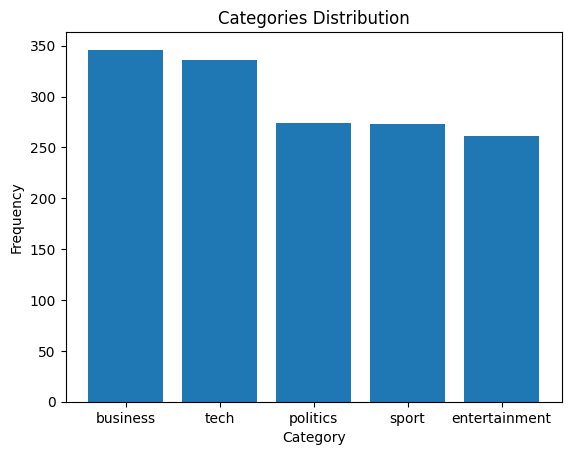

In [5]:
# Visualize category distribution
plt.bar(x=category_names, height=value_counts)
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

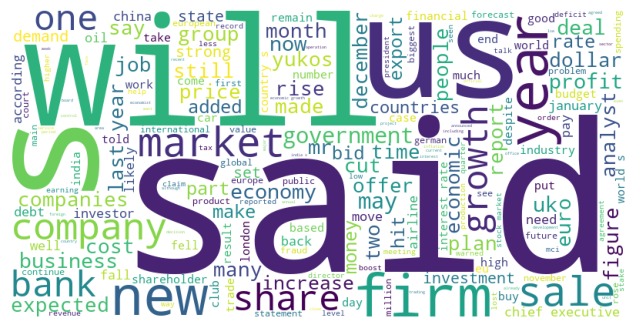

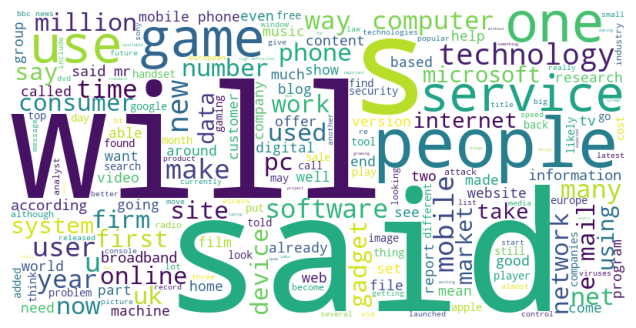

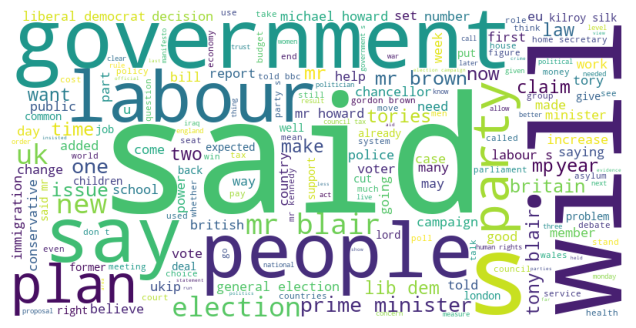

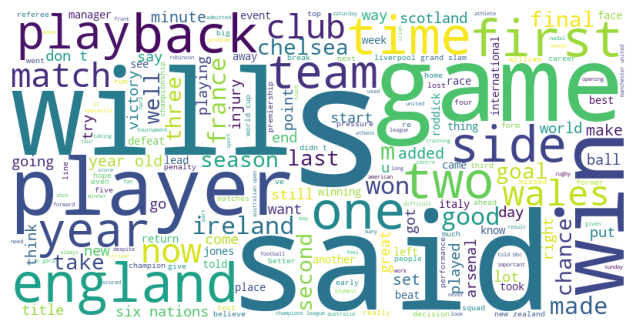

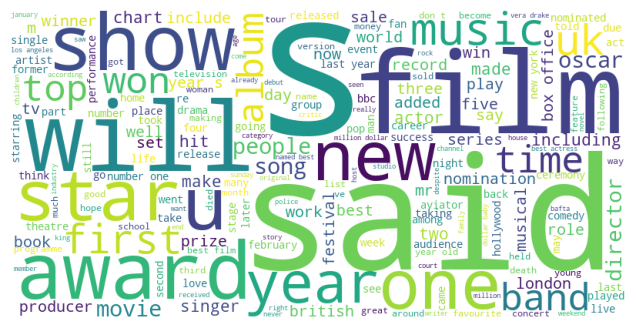

In [6]:
# Generate a wordcloud
for category in category_names:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800,height=400,background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [7]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
# Build Model
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)

model.fit(X_train,y_train)
y_pred= model.predict(X_test)

In [9]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



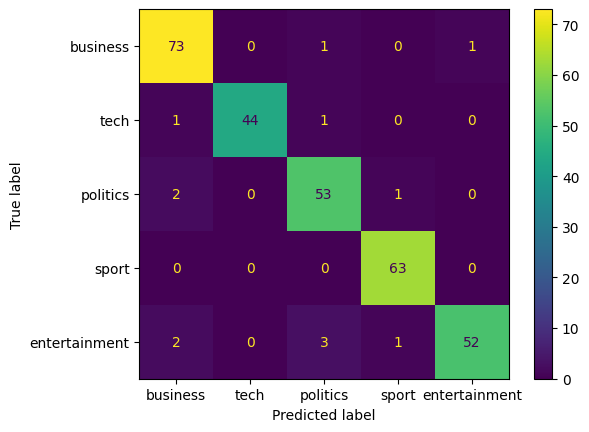

In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,display_labels=category_names).plot()

In [11]:
# Test with New Articles
texts = ['King Birendra has died']
prediction = model.predict(texts)
print(prediction)

['entertainment']


In [12]:
# Save Model
import joblib
joblib.dump(model, 'model.joblib')
print("SUCCESS")

SUCCESS


### Evaluation of the model using Accuracy, Precision, Recall, and F1-Score

In [13]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted') 

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9563758389261745
Precision: 0.9574896655178124
Recall: 0.9563758389261745
F1 Score: 0.9562904295627416


The model achieved a high accuracy in classifying news articles into different categories. The weighted precision indicates that most of the predicted categories are correct. The weighted recall shows that the model successfully identified the majority of articles belonging to each category. The weighted F1-score, being the harmonic mean of precision and recall, also indicates strong overall performance. Since all evaluation metrics are high and close to each other, the model performs consistently across different news categories.

###  Experiment with TF-IDF parameters such as max_features, ngram_range, and min_df

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model1 = make_pipeline(
    TfidfVectorizer(
        stop_words='english',
        max_features=1000
    ),
    MultinomialNB()
)

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

accuracy1 = accuracy_score(y_test, y_pred1)

print("Accuracy (max_features=1000):", accuracy1)

Accuracy (max_features=1000): 0.9664429530201343


In [15]:
# max_features reduces noise and improve efficiency
# ngram_range captures meaningful word combination
# min_df removes very rare words.


model2 = make_pipeline(
    TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2)
    ),
    MultinomialNB()
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

accuracy2 = accuracy_score(y_test, y_pred2)

print("Accuracy (ngram_range=(1,2)):", accuracy2)

Accuracy (ngram_range=(1,2)): 0.9630872483221476


In [16]:
model3 = make_pipeline(
    TfidfVectorizer(
        stop_words='english',
        min_df=2
    ),
    MultinomialNB()
)

model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

accuracy3 = accuracy_score(y_test, y_pred3)

print("Accuracy (min_df=2):", accuracy3)

Accuracy (min_df=2): 0.9630872483221476


The TF-IDF parameter experiments showed only a small effect on the model's performance. Using max_features=1000 achieved the highest accuracy of 96.64%, while both ngram_range=(1,2) and min_df=2 resulted in a slightly lower accuracy of 96.31%. Overall, the default TF-IDF configuration and the max_features setting performed slightly better than the other parameter variations, indicating that limiting features to the most important words was beneficial for this dataset.

### Classification of at least five custom news articles

In [17]:
# Five custom news articles

texts = [
    "The government has announced a new tax policy to improve the country's economy and reduce inflation.",

    "The national football team won the championship after defeating their opponent in a thrilling final match.",

    "A leading smartphone company has launched a new AI-powered flagship device with advanced camera features.",

    "The latest blockbuster movie has broken all box office records and received positive reviews from critics.",

    "The stock market reached a record high as investors showed confidence in the banking sector."
]

# Predict categories
predictions = model.predict(texts)

# Display results
for i in range(len(texts)):
    print(f"\nArticle {i+1}:")
    print(texts[i])
    print("Predicted Category:", predictions[i])


Article 1:
The government has announced a new tax policy to improve the country's economy and reduce inflation.
Predicted Category: business

Article 2:
The national football team won the championship after defeating their opponent in a thrilling final match.
Predicted Category: sport

Article 3:
A leading smartphone company has launched a new AI-powered flagship device with advanced camera features.
Predicted Category: tech

Article 4:
The latest blockbuster movie has broken all box office records and received positive reviews from critics.
Predicted Category: entertainment

Article 5:
The stock market reached a record high as investors showed confidence in the banking sector.
Predicted Category: business


###  Saved the trained model and reloaded it to perform predictions on new data

In [18]:
# Load the saved model
loaded_model = joblib.load("model.joblib")
print("Model loaded successfully.")

Model loaded successfully.


In [19]:
news_article = [
    "Scientists have developed a new artificial intelligence system that can diagnoses more accurately."
]

prediction = loaded_model.predict(news_article)
print("Predicted category:", prediction[0])

Predicted category: politics


### Train-Test Split Ratio

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Different train-test split ratios
splits = [0.3, 0.2, 0.1]

results = []

for test_size in splits:
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    # Create model
    model = make_pipeline(
        TfidfVectorizer(stop_words='english'),
        MultinomialNB()
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append((1-test_size, test_size, accuracy))

In [21]:
print("Train %\tTest %\tAccuracy")

for train_ratio, test_ratio, accuracy in results:
    print(f"{int(train_ratio*100)}%\t{int(test_ratio*100)}%\t{accuracy:.4f}")
    

Train %	Test %	Accuracy
70%	30%	0.9687
80%	20%	0.9564
90%	10%	0.9597


### 5-Fold Cross Validation,Mean Accuracy and Standard Deviation 

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import numpy as np

# Build the model
model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)

# Perform 5-Fold Cross Validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Accuracy for each fold:")
print(scores)

print("\nMean Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

Accuracy for each fold:
[0.96308725 0.95302013 0.96979866 0.97986577 0.96644295]

Mean Accuracy: 0.9664429530201343
Standard Deviation: 0.00875060725530559


A 5-Fold Cross Validation was performed to evaluate the stability of the Multinomial Naïve Bayes model. The model achieved a mean accuracy of 96.64% with a standard deviation of 0.0088. The low standard deviation indicates that the accuracy remained consistent across all five folds. Therefore, the model is considered stable and generalizes well to unseen news articles.

###  Multinomial Naïve Bayes,Logistic Regression,Support Vector Machine (SVM)

In [23]:
import time
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score

In [24]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": LinearSVC()
}

In [25]:
results = []

for name, classifier in models.items():

    model = make_pipeline(
        TfidfVectorizer(stop_words='english'),
        classifier
    )

    # Training Time
    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()

    training_time = end_train - start_train

    # Prediction Time
    start_predict = time.time()
    y_pred = model.predict(X_test)
    end_predict = time.time()

    prediction_time = end_predict - start_predict

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        training_time,
        prediction_time
    ])

In [26]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Training Time (s)",
        "Prediction Time (s)"
    ]
)

comparison

,Model,Accuracy,Training Time (s),Prediction Time (s)
0,Multinomial Naive Bayes,0.959732,0.502968,0.047868
1,Logistic Regression,0.966443,1.262401,0.055848
2,Support Vector Machine,1.000000,0.591130,0.059998


###  News Recommendation Prototype

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Fit TF-IDF on the entire dataset
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(df['Text'])

# Enter a News article
new_article = [
    "FIFA world cup 2026 has started."
]

# Predict the category
predicted_category = model.predict(new_article)[0]

print("Predicted Category:", predicted_category)


# Get articles from the same category
same_category = df[df['Category'] == predicted_category]

# Create TF-IDF for those articles
same_category_matrix = vectorizer.transform(same_category['Text'])

new_article_vector = vectorizer.transform(new_article)


# cosine similarity
similarities = cosine_similarity(
    new_article_vector,
    same_category_matrix
)

# Top 3 similar Articles
top3 = similarities.argsort()[0][-3:][::-1]

print("\nRecommended Articles:\n")

for i in top3:
    print(same_category.iloc[i]['Text'][:300])
    print("Category:", same_category.iloc[i]['Category'])


Predicted Category: sport

Recommended Articles:

republic to face china and italy the republic of ireland have arranged friendlies against china and italy which will take place at lansdowne road in march and august.  brian kerr s side will face the 54th ranked chinese on 29 march - just three days after the world cup qualifier against israel in te
Category: sport
henman decides to quit davis cup tim henman has retired from great britain s davis cup team.  the 30-year-old  who made his davis cup debut in 1994  is now set to fully focus on the atp tour and on winning his first grand slam event.  i ve made no secret of the fact that representing great britain h
Category: sport
moya sidesteps davis cup in 2005 carlos moya has chosen not to help spain try and defend the davis cup crown they won in seville in november.  moya led spain to victory over the usa but wants to focus on the grand slams in 2005  although insists he will return to the davis cup in 2006.  after two ye
Category: sport